In [ ]:
%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

env: PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True


# Norwegian Book Review Summarization Pipeline

End-to-end NLP pipeline that refines **218,837 Norwegian book reviews** into concise, per-book abstract summaries, from raw data to fine-tuned models, including an additional (possible) REST service, and agent integration.

## Architecture

```text
Raw reviews (218,837)
        ↓
Preprocessing
        ↓
Top 40 most-reviewed books (1,828 reviews)
        ↓
NorBERT3-TSA
        ↓
Target-aware sentiment tagging per review
(positive / negative spans)
        ↓
Aggregation
        ↓
Structured sentiment snippet input per book
        ↓
Fine-tuned LLMs (×2)
• 4-bit quantised QLoRA
• Beam-search decoding

• GloriaABK1/llama-2-7b-chat-norwegian-sum
• GloriaABK1/normistral-7b-warm-norsumm
        ↓
ROUGE-L evaluation
        ↓
Quantitative model comparison
        ↓
Extended integrations
• Commercial API comparison
  (Claude claude-opus-4-8 via Anthropic SDK)

• FastAPI service layer
  (REST endpoint, Pydantic schemas, lifespan model loading)

• MCP server
  (exposes summarization as an agent-callable tool)

• Local deployment notes
  (Ollama / vLLM, GDPR and data-residency considerations)

# Imports and downloads

In [ ]:
# Installations
!pip install -U spacy
!python -m spacy download nb_core_news_sm
!pip install transformers
!pip install langdetect
!pip install -U bitsandbytes
!pip install --upgrade accelerate transformers
!pip install -q huggingface_hub
!pip install rouge_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 120.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('nb_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=994dcce4eb37b41e4cfb988206e98a51cd71fea2c1533c0f56ce666effe78dde
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━

In [ ]:
#Imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
import spacy
from sklearn.model_selection import train_test_split
import torch
from transformers import AutoTokenizer, BitsAndBytesConfig, AutoModelForCausalLM, pipeline
from huggingface_hub import notebook_login
import itertools
from tqdm import tqdm

torch.cuda.empty_cache()

# Part 1 - QLoRA Fine-tuning

Both Norwegian LLMs are fine-tuned with **QLoRA** on the
[NorSumm](https://huggingface.co/datasets/SamiaT/NorSumm) dataset (Bokmål + Nynorsk, merged and shuffled).
The same script is used for both models: run **one** model-name cell at a time before training.

| Hyperparameter | Value |
|---|---|
| LoRA rank (r) | 32 |
| LoRA alpha | 64 |
| LoRA dropout | 0.05 |
| Quantisation | 4-bit NF4 |
| Optimiser | paged_adamw_8bit |
| Learning rate | 1e-5 |
| Epochs | 4 (early stopping on ROUGE-L) |
| Target modules | q, k, v, o, gate, up, down, lm_head |


In [ ]:
# Fine-tuning dependencies
!pip install -q -U git+https://github.com/huggingface/peft.git
!pip install -q -U git+https://github.com/huggingface/accelerate.git
!pip install -q datasets trl evaluate
!huggingface-cli login


In [ ]:
from peft import LoraConfig, get_peft_model, PeftModel
from trl import SFTTrainer
from datasets import Dataset, DatasetDict, load_dataset, concatenate_datasets
from transformers import EarlyStoppingCallback, TrainingArguments
import evaluate
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize


In [ ]:
# Prepend both the CUDA toolkit path and the system's GPU-driver path:
os.environ["LD_LIBRARY_PATH"] = (
    "/usr/local/cuda/lib64:/usr/lib/x86_64-linux-gnu:"
    + os.environ.get("LD_LIBRARY_PATH", "")
)

**Note:** The same fine-tuning script was used for both base models.
Run **one** of the two model-name cells below (NorMistral or Llama-2) before executing the rest of the section.
The output adapter is saved locally and pushed to the Hugging Face Hub to `GloriaABK1/`.


In [ ]:
# Downloading the normistral-7b-warm model from hugging face
model_name = "norallm/normistral-7b-warm"

# The summarization dataset
dataset_name = "SamiaT/NorSumm"

# Fine-tuned model name
new_model = "norallm/normistral-7b-warm-norsumm"

In [ ]:
# Downloading the llama-2-7b-chat-norwegian huggingface
model_name = "RuterNorway/Llama-2-7b-chat-norwegian"

# The summarization dataset
dataset_name = "SamiaT/NorSumm"

# Fine-tuned model name
new_model = "Llama-2-7b-chat-norwegian-sum"

In [ ]:
# LoRA attention dimension
lora_r = 32

# Alpha parameter for LoRA scaling
lora_alpha = 64

# Dropout probability for LoRA layers
lora_dropout = 0.05 # per recommendations from the original QLoRA (LoRA dropout = 0.05 for small models (7B, 13B))

In [ ]:
################################################################################
# bitsandbytes parameters
################################################################################

# Activate 4-bit precision base model loading
use_4bit = True

# Compute dtype for 4-bit base models
bnb_4bit_compute_dtype = "float16"

# Quantization type (fp4 or nf4)
bnb_4bit_quant_type = "nf4"

# Activate nested quantization for 4-bit base models (double quantization)
use_nested_quant = False

In [ ]:
################################################################################
# TrainingArguments parameters
################################################################################
callbacks = [EarlyStoppingCallback(early_stopping_patience=1)]

# Output directory where the model predictions and checkpoints will be stored
output_dir = "./results"

# Number of training epochs
num_train_epochs = 4

# Enable fp16/bf16 training
fp16 = False
bf16 = True

# Saving strategy
save_strategy = "epoch"


# Batch size per GPU for training
per_device_train_batch_size = 4

# Batch size per GPU for evaluation
per_device_eval_batch_size = 4

# Number of update steps to accumulate the gradients for
gradient_accumulation_steps = 2

# Enable gradient checkpointing
gradient_checkpointing = True

# Maximum gradient normal (gradient clipping)
max_grad_norm = 0.3

# Initial learning rate (AdamW optimizer)
learning_rate = 1e-5

# Weight decay to apply to all layers except bias/LayerNorm weights
weight_decay = 0.001

# Optimizer
optim = "paged_adamw_8bit"

# Learning rate schedule
lr_scheduler_type = "constant"

# Ratio of steps for a linear warmup
warmup_ratio = 0.03

# Saves memory and speeds up training considerably
group_by_length = True


# Log every X updates steps
logging_steps = 4

In [ ]:
################################################################################
# SFT parameters
################################################################################

# Load the entire model on the GPU 0
device_map = {"": 0}

In [ ]:
# Loading NorSumm dataset
dataset_nb = load_dataset("samiat/norSumm", "nb")
dataset_nn = load_dataset("samiat/norSumm", "nn")
# Checking the splits of the dataset
print(f"Bokmål dataset: {dataset_nb}, Nynorsk: {dataset_nn}")

In [ ]:
def show_samples(dataset, num_samples=3, seed=42):
    sample = dataset["validation"].shuffle(seed=seed).select(range(num_samples))
    for example in sample:
        print(f"\n'>> Article: {example['article']}'")
        print(f"'>> Summaries: {example['summaries']}'")


show_samples(dataset_nb) # Just an example

In [ ]:
# Merge each split of the HF DatasetDicts
combined_df = DatasetDict()
for split in dataset_nn.keys():
    combined_df[split] = concatenate_datasets(
        [dataset_nn[split], dataset_nb[split]]
    )
    combined_df[split] = combined_df[split].shuffle(seed=42)

# Peek at a few examples
show_samples(combined_df)

In [ ]:
# 1) Split the validation set into train / val
split = combined_df["validation"].train_test_split(test_size=0.2, seed=42)
train_ds = split["train"]       # ~80% of those ~60 examples
val_ds   = split["test"]        # ~20% of those ~60 examples

# 2) Keep combined test as-is
test_ds  = combined_df["test"]

# 3) Assemble final 3-way DatasetDict
full_ds = DatasetDict({
    "train":      train_ds,
    "validation": val_ds,
    "test":       test_ds,
})

print({k: v.num_rows for k, v in full_ds.items()})

In [ ]:
exploded = {}
for split_name, ds in full_ds.items():
    # pandas DataFrame
    df = ds.to_pandas().reset_index(drop=True)

    # explode the 'summaries' list so each row has one summary string
    df = df.explode("summaries").reset_index(drop=True)

    # convert back to a huggingface Dataset
    exploded[split_name] = Dataset.from_pandas(df, preserve_index=False)

# reassemble as a DatasetDict
exploded = DatasetDict(exploded)

print({k: v.num_rows for k, v in exploded.items()})

In [ ]:
# Load tokenizer and model with QLoRA configuration
compute_dtype = getattr(torch, bnb_4bit_compute_dtype)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=use_4bit,
    bnb_4bit_quant_type=bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=use_nested_quant,
)

In [ ]:
# Check GPU compatibility with bfloat16
if compute_dtype == torch.float16 and use_4bit:
    major, _ = torch.cuda.get_device_capability()
    if major >= 8:
        print("=" * 80)
        print("Your GPU supports bfloat16: accelerate training with bf16=True")
        print("=" * 80)

In [ ]:
# Load base model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map
)
model.config.use_cache = False
model.config.pretraining_tp = 1

In [ ]:
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}"
    )

In [ ]:
# See how many trainable parameters and percentage

print_trainable_parameters(model)

In [ ]:
# Load tokenizer — pad_token set to eos_token (right-padding for causal LM)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

In [ ]:
max_input_length  = 512
max_target_length = 120

def preprocess_function(examples):
    # make everything to plain Python str
    articles  = [str(a) for a in examples["article"]]
    summaries = [str(s) for s in examples["summaries"]]


    # tokenize inputs and targets
    model_inputs = tokenizer(
        articles,
        max_length=max_input_length,
        truncation=True,
    )
    labels = tokenizer(
        summaries,
        max_length=max_target_length,
        truncation=True,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


tokenized = exploded.map(preprocess_function, batched=True)

In [ ]:
# Define train, evaluation and test dataset
train_dataset = tokenized["train"]
eval_dataset  = tokenized["validation"]
test_dataset  = tokenized["test"]

In [ ]:
# Import rouge metrics
rouge_score = evaluate.load("rouge")

In [ ]:
def postprocess_text(preds, labels):
    """
    Postprocesses the predictions and labels to remove extra whitespace and newlines.
    """
    preds = [pred.strip() for pred in preds]
    labels = [label.strip() for label in labels]

    preds = ["\n".join(sent_tokenize(pred)) for pred in preds]
    labels = ["\n".join(sent_tokenize(label)) for label in labels]

    return preds, labels

def compute_metrics(eval_pred):
    logits, labels = eval_pred


    if isinstance(logits, tuple):
        logits = logits[0]


    # Convert to predicted token IDs by argmax over vocab dimension
    pred_ids = np.argmax(logits, axis=-1)

    # Cast labels to a NumPy array to make masking easy
    labels = np.array(labels)

    # Replace -100 with pad_token_id so that decode works correctly
    labels = np.where(labels == -100,
                      tokenizer.pad_token_id,
                      labels)

    # Decode
    decoded_preds  = tokenizer.batch_decode(
        pred_ids, skip_special_tokens=True
    )
    decoded_labels = tokenizer.batch_decode(
        labels,  skip_special_tokens=True
    )


    decoded_preds, decoded_labels = postprocess_text(
        decoded_preds, decoded_labels
    )
    result = rouge_score.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )
    # format the scores
    final_scores = {
      k: round((v.mid.fmeasure if hasattr(v, "mid") else v) * 100, 4)
      for k, v in result.items()
    }
    return final_scores


In [ ]:
# Load LoRA configuration
peft_config = LoraConfig(

    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    r=lora_r,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj","k_proj","v_proj","o_proj",
        "gate_proj","up_proj","down_proj","lm_head" ]
)

model = get_peft_model(model, peft_config)

In [ ]:
# training parameters
training_arguments = TrainingArguments(
    auto_find_batch_size=True,
    output_dir=output_dir,
    num_train_epochs=num_train_epochs,
    gradient_accumulation_steps=gradient_accumulation_steps,
    optim=optim,
    save_strategy=save_strategy,
    eval_strategy="epoch",
    logging_strategy="steps",
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    logging_steps=logging_steps,
    fp16=fp16,
    bf16=bf16,
    load_best_model_at_end=True,
    metric_for_best_model="eval_rougeL",    # checking for ROUGE-L F1
    greater_is_better=True,
    max_grad_norm=max_grad_norm,
    warmup_ratio=warmup_ratio,
    group_by_length=group_by_length,
    lr_scheduler_type=lr_scheduler_type,
    report_to="tensorboard",
    overwrite_output_dir=True

)

In [ ]:
# supervised fine-tuning parameters
trainer = SFTTrainer(
    model=model,
    eval_dataset=eval_dataset,
    train_dataset=train_dataset,
    peft_config=peft_config,
    args=training_arguments,
    compute_metrics=compute_metrics,
    callbacks=callbacks,

)

In [ ]:
# Fine-tune the LoRA-adapted model
trainer.train()

In [ ]:
trainer.model.save_pretrained(new_model)
tokenizer.save_pretrained(new_model)

# Push adapter weights + tokenizer to the Hub under your account
trainer.model.push_to_hub(f"GloriaABK1/{new_model}")
tokenizer.push_to_hub(f"GloriaABK1/{new_model}")


In [ ]:
# Evaluate on the validation set (best checkpoint loaded via load_best_model_at_end)
trainer.evaluate()

In [ ]:
test_metrics = trainer.evaluate(test_dataset)
print(test_metrics)

# Part 2 - Book Review Summarization Pipeline

With both fine-tuned models pushed to Hugging Face, this section runs the full
inference pipeline on the Bokelskere.no Norwegian book review corpus.


# Preprocessing

In [ ]:
#Loading the data
with open("2019_bokelskere.json", "r", encoding="utf-8") as f:
  data = json.load(f)

In [ ]:
#Defining the data as a pandas dataframe
df = pd.DataFrame(data)

In [ ]:
df.columns

Index(['post_id', 'date', 'user_id', 'isbn13', 'post_title', 'text', 'score',
       'main_title', 'author', 'parent_id'],
      dtype='object')

In [ ]:
df.head()

,post_id,date,user_id,isbn13,post_title,text,score,main_title,author,parent_id
0,1,2009-07-13 11:06:43,6,9788203207617,,"Jeg digger Drangers illustrasjonsstil, og så e...",5,"""Frøken Livredd og Kjærligheten""","""Joanna Rubin Dranger""",NULL
1,2,2009-07-11 16:50:46,9,9788281431379,,Bra krimbok. Lettlest og fine skildringer av p...,5,"""En helt annen historie""","""Håkan Nesser""",NULL
2,3,2009-07-11 16:48:00,9,9788205390010,,Selv om det var bok nummer 1 i serien og jeg l...,5,"""Isprinsessen""","""Camilla Läckberg""",NULL
3,6,2009-07-11 16:45:47,9,9788205381506,,Synes at historien drives framover. Enkelt sp...,6,"""Ulykkesfuglen""","""Camilla Läckberg""",NULL
4,13,2009-07-05 14:36:19,11,9788205277489,,Mesterverk. Paranoid mesterverk. Tenk å starte...,6,"""Sult""","""Knut Hamsun""",NULL


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218937 entries, 0 to 218936
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   post_id     218937 non-null  object
 1   date        218937 non-null  object
 2   user_id     218937 non-null  object
 3   isbn13      218937 non-null  object
 4   post_title  218937 non-null  object
 5   text        218937 non-null  object
 6   score       218937 non-null  object
 7   main_title  218937 non-null  object
 8   author      218937 non-null  object
 9   parent_id   218937 non-null  object
dtypes: object(10)
memory usage: 16.7+ MB


In [ ]:
# Checking if there are missing values in the dataframe
df.isnull().sum()

,0
post_id,0
date,0
user_id,0
isbn13,0
post_title,0
text,0
score,0
main_title,0
author,0
parent_id,0


In [ ]:
# Because the dataset shows that a lot of the columns have 'NULL' instead of missing values, we need to find these.
df.replace("NULL", np.nan, inplace=True)
df.isnull().sum()

,0
post_id,0
date,0
user_id,0
isbn13,167765
post_title,0
text,0
score,175822
main_title,165411
author,165554
parent_id,65340


In [ ]:
# Checking for missing values in 'main_title'
missing_main_title = df['main_title'].isnull().sum()
print(f"Number of missing 'main_title': {missing_main_title}")

Number of missing 'main_title': 165411


In [ ]:
# Removing missing values in 'main_title'
df.dropna(subset=['main_title'], inplace=True)

In [ ]:
missing_main_title = df['main_title'].isnull().sum()
print(f"Number of missing 'main_title': {missing_main_title}")

Number of missing 'main_title': 0


In [ ]:
#Computing total number of reviews and unique books (using 'main_title' as the book identifier)
total_reviews = len(df)
unique_books = df['main_title'].nunique()

#Print total reviews and unique books
print(f"Total Reviews: {total_reviews}, Unique Books: {unique_books}\n")

#Computing and print summary statistics for the 'score' column
print("Summary Statistics for 'score' column:")
print(df['score'].describe())

Total Reviews: 53526, Unique Books: 24311

Summary Statistics for 'score' column:
count     43059
unique        6
top           5
freq      16406
Name: score, dtype: object


In [ ]:
#Grouping reviews by 'main_title' and counting the number of reviews per book using the 'text' column
review_count = df.groupby('main_title')['text'].count().reset_index(name='review_count')

print(review_count.sort_values(by='review_count', ascending=False).head())

                                              main_title  review_count
13990                                         "Min kamp"           123
9642   "Hundreåringen som klatret ut gjennom vinduet ...            96
6491                                  "Et helt halvt år"            94
6108                              "En mann ved navn Ove"            79
24292                                              "Øya"            74


In [ ]:
#Keeping only the top 40 most reviewed main titles
main_title = review_count.sort_values(by='review_count', ascending=False).head(40)['main_title']
df = df[df['main_title'].isin(main_title)].copy()

In [ ]:
#Checking for missing values in 'score' column
missing_score = df['score'].isnull().sum()
print(f"Number of missing 'score': {missing_score}")

Number of missing 'score': 344


In [ ]:
unique_scores = df['score'].unique()
print("Unique scores:", unique_scores)

Unique scores: ['5' '6' nan '2' '4' '3' '1']


In [ ]:
#Any values that cannot be converted are set to NaN
df['score'] = pd.to_numeric(df['score'], errors='coerce')

df.loc[df['score'] > 6, 'score'] = np.nan

df.dropna(subset=['score'], inplace=True)
df.reset_index(drop=True, inplace=True)

<ipython-input-20-bf469d638425>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['score'] = pd.to_numeric(df['score'], errors='coerce')
<ipython-input-20-bf469d638425>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['score'], inplace=True)


In [ ]:
missing_score = df['score'].isnull().sum()
print(f"Number of missing 'score': {missing_score}")

Number of missing 'score': 0


In [ ]:
print(df['score'].value_counts())

score
6.0    719
5.0    597
4.0    269
3.0    129
2.0     71
1.0     43
Name: count, dtype: int64


In [ ]:
# Creating a new column of mean score for each main title and their associated scores
df['mean_score'] = df.groupby('main_title')['score'].transform('mean').round(1)

<ipython-input-23-7f393a3c382f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mean_score'] = df.groupby('main_title')['score'].transform('mean').round(1)


## Visualizations

<ipython-input-24-9fef30ec51ab>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='main_title', y='review_count', data=top_books, palette='viridis')


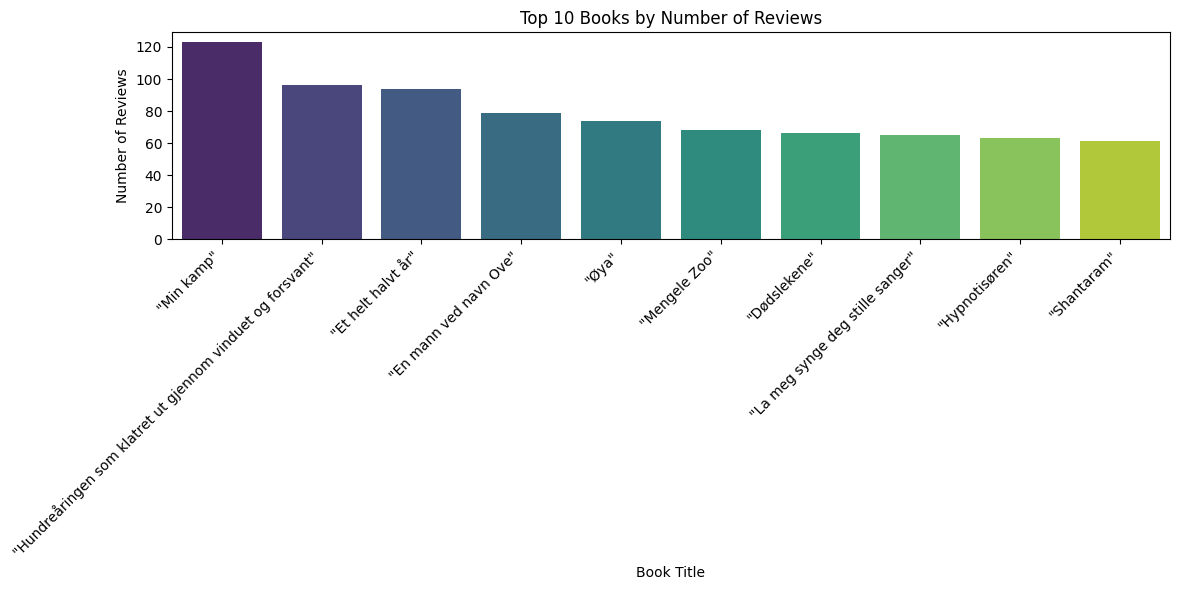

In [ ]:
#Visualizing top 10 books by number of reviews
top_books = review_count.sort_values(by='review_count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='main_title', y='review_count', data=top_books, palette='viridis')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Book Title')
plt.ylabel('Number of Reviews')
plt.title('Top 10 Books by Number of Reviews')

plt.tight_layout()

plt.show()

<ipython-input-25-2819f589d2db>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.values, y=top_authors.index, palette='viridis')


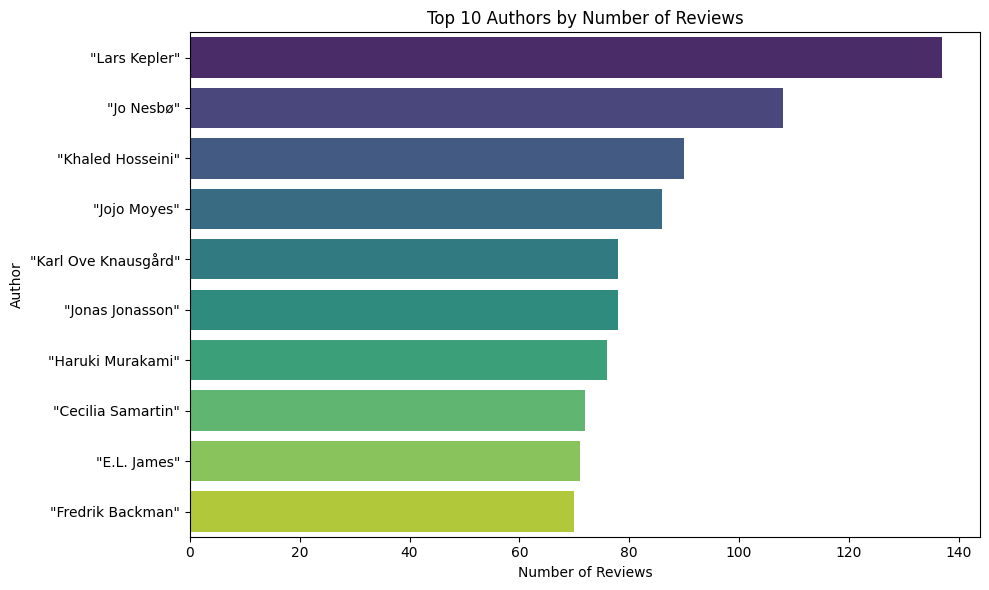

In [ ]:
# Visualization of top 10 authors
top_authors = df['author'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='viridis')
plt.xlabel('Number of Reviews')
plt.ylabel('Author')
plt.title('Top 10 Authors by Number of Reviews')
plt.tight_layout()
plt.show()

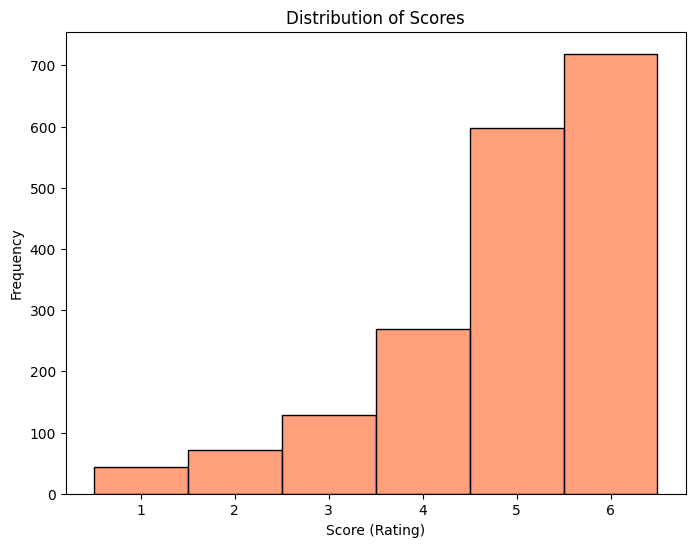

In [ ]:
#Visualizing distribution of scores
plt.figure(figsize=(8, 6))

sns.histplot(df['score'].astype(float), bins=range(1, 8), discrete=True, color='coral', edgecolor='black')

plt.xlabel('Score (Rating)')
plt.ylabel('Frequency')
plt.title('Distribution of Scores')

plt.xticks(range(1, 7))

plt.show()

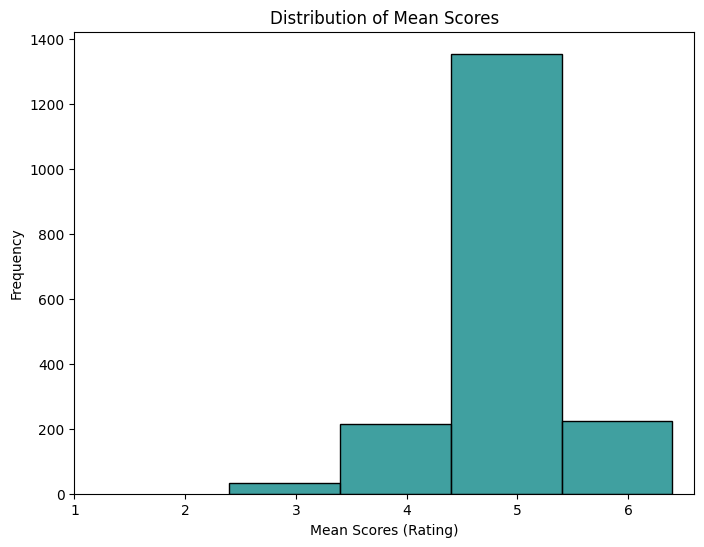

In [ ]:
# Vizualising the mean_score column
plt.figure(figsize=(8, 6))

sns.histplot(df['mean_score'].astype(float), bins=range(1, 8), discrete=True, color='teal', edgecolor='black')

plt.xlabel('Mean Scores (Rating)')
plt.ylabel('Frequency')
plt.title('Distribution of Mean Scores')

plt.xticks(range(1, 7))

plt.show()

In [ ]:
num_missing_text = df['text'].isna().sum()
print(f"Number of missing text: {num_missing_text}")

Number of missing text: 0


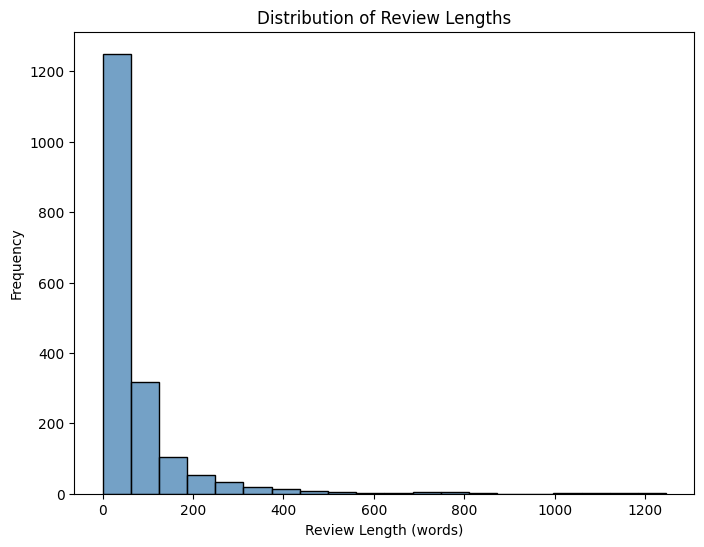

In [ ]:
#Visualizing distribution of review lengths
df['review_length'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 6))

sns.histplot(df['review_length'], bins=20, color='steelblue', edgecolor='black')

plt.xlabel('Review Length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths')

plt.show()

In [ ]:
# Calculating text statistics
average_length = df['review_length'].mean()
max_length = df['review_length'].max()
min_length = df['review_length'].min()


print("Review Length Statistics")
print("-------------------------")
print(f"Average review length : {average_length:.2f} words")
print(f"Longest review        : {max_length} words")
print(f"Shortest review       : {min_length} words")

Review Length Statistics
-------------------------
Average review length : 72.37 words
Longest review        : 1247 words
Shortest review       : 0 words


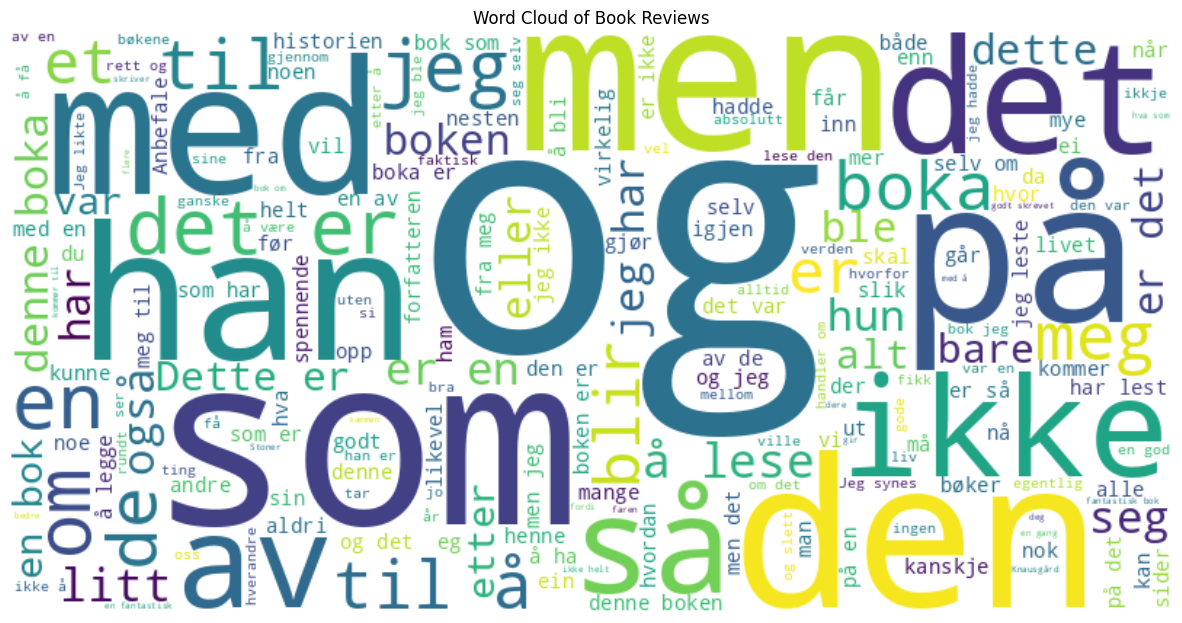

In [ ]:
all_text = " ".join(df['text'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(all_text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Book Reviews")
plt.show()

### Defining a smaller df

In [ ]:
columns_to_keep = ['text', 'mean_score', 'main_title', 'author']
df = df[columns_to_keep]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1828 entries, 0 to 1827
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   text        1828 non-null   object 
 1   mean_score  1828 non-null   float64
 2   main_title  1828 non-null   object 
 3   author      1828 non-null   object 
dtypes: float64(1), object(3)
memory usage: 57.3+ KB


In [ ]:
df.head()

,text,mean_score,main_title,author
0,"Boka klarer å holde oppe spenningen, og skildr...",4.7,"""Mengele Zoo""","""Gert Nygårdshaug"""
1,"Kanskje dette er den beste boka, rett og slett?\n",5.2,"""The road""","""Cormac McCarthy"""
2,[Filmatiseringen av denne](http://www.apple.co...,5.2,"""The road""","""Cormac McCarthy"""
3,Hvis jeg hører noen snakke negativt om denne b...,5.2,"""The road""","""Cormac McCarthy"""
4,Det blir ikke særlig mye bedre enn dette!\nLur...,5.2,"""The road""","""Cormac McCarthy"""


## Text preprocessing

In [ ]:
'''
Here we're going to lightly clean the reviews by making stripping urls,
removing all digits that may show up in the review and strip long words that can confuse the model,
we also want to only keep letters and spaces and collapse whitespace.
'''

KEEP_PUNCT = r"\.\,\!\?\:\;\"\'\(\)\-\–\—\…"

def clean_text(text):

    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'\d+', ' ', text)


    text = re.sub(
        rf"[^A-Za-zÆØÅæøå\s{KEEP_PUNCT}]",
        " ",
        text
    )

    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)
df = df[df['cleaned_text'] != ""]

In [ ]:
df.head()

,text,mean_score,main_title,author,cleaned_text
0,"Boka klarer å holde oppe spenningen, og skildr...",4.7,"""Mengele Zoo""","""Gert Nygårdshaug""","Boka klarer å holde oppe spenningen, og skildr..."
1,"Kanskje dette er den beste boka, rett og slett?\n",5.2,"""The road""","""Cormac McCarthy""","Kanskje dette er den beste boka, rett og slett?"
2,[Filmatiseringen av denne](http://www.apple.co...,5.2,"""The road""","""Cormac McCarthy""","Filmatiseringen av denne ( kommer i oktober , ..."
3,Hvis jeg hører noen snakke negativt om denne b...,5.2,"""The road""","""Cormac McCarthy""",Hvis jeg hører noen snakke negativt om denne b...
4,Det blir ikke særlig mye bedre enn dette!\nLur...,5.2,"""The road""","""Cormac McCarthy""",Det blir ikke særlig mye bedre enn dette! Lure...


# Sentiment analysis - NorBert3 TSA

In [ ]:
notebook_login()

In [ ]:
# Initial load, superseded by the configured pipeline in the next cell
pipe = pipeline("token-classification", model="ltg/norbert3-large_TSA", trust_remote_code=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.55k [00:00<?, ?B/s]

configuration_norbert.py:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ltg/norbert3-large_TSA:
- configuration_norbert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_norbert.py:   0%|          | 0.00/28.5k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ltg/norbert3-large_TSA:
- modeling_norbert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/1.47G [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
'''
Quick start from Hugging face, modified.
'''

origin       = "ltg/norbert3-large_TSA"
trust_remote = "norbert3" in origin.lower()

if trust_remote:
    pipe = pipeline(
        "token-classification",
        aggregation_strategy="first",
        model=origin,
        tokenizer=AutoTokenizer.from_pretrained(origin),
        trust_remote_code=True,
    )
else:
    pipe = pipeline(
        "token-classification",
        model=origin,
        tokenizer=AutoTokenizer.from_pretrained(origin),
    )

text = df.loc[0, "cleaned_text"]

preds = pipe(text)

for p in preds:
    print(p)

tokenizer_config.json:   0%|          | 0.00/18.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.26M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/971 [00:00<?, ?B/s]

Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


{'entity_group': 'targ-Positive', 'score': np.float32(0.7569457), 'word': 'Boka', 'start': 0, 'end': 4}
{'entity_group': 'targ-Positive', 'score': np.float32(0.7028128), 'word': ' skildringen av miljø og personer', 'start': 39, 'end': 72}


/usr/local/lib/python3.11/dist-packages/transformers/pipelines/token_classification.py:398: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(


In [ ]:
'''
Performing the sentiment analysis on the entire dataset.
Grouping the results into positive and negative snippets.
'''
tqdm.pandas()
def group_snippets(preds):
    snippets = {"Positive": [], "Negative": []}
    current, current_label = [], None
    for p in preds:
        label = p["entity_group"].split("-")[-1]
        word  = p["word"]
        if label in snippets:
            if current_label != label:
                if current:
                    snippets[current_label].append(" ".join(current))
                current, current_label = [word], label
            else:
                current.append(word)
        else:
            if current:
                snippets[current_label].append(" ".join(current))
                current, current_label = [], None
    if current:
        snippets[current_label].append(" ".join(current))
    return snippets

df['preds'] = df['cleaned_text'].progress_apply(pipe)

# New columns
df['snippets'] = df['preds'].apply(group_snippets)
df['positive_snippets'] = df['snippets'].apply(lambda s: s['Positive'])
df['negative_snippets'] = df['snippets'].apply(lambda s: s['Negative'])
df['pos_count'] = df['positive_snippets'].apply(len)
df['neg_count'] = df['negative_snippets'].apply(len)

  0%|          | 0/1824 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/pipelines/token_classification.py:398: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(
100%|██████████| 1824/1824 [01:16<00:00, 23.97it/s]


In [ ]:
# Grouping the aggregated lists
df_grouped = (
    df
    .groupby("main_title", as_index=False)
    .agg(
        author              = ("author",      "first"),
        mean_score          = ("mean_score",  "mean"),
        agg_cleaned_text    = ("cleaned_text", lambda texts: " ".join(texts)),
        agg_text            = ("text",         lambda texts: " ".join(texts)),

        positive_snippets   = (
            "positive_snippets",
            lambda lists: list(itertools.chain.from_iterable(lists))
        ),
        negative_snippets   = (
            "negative_snippets",
            lambda lists: list(itertools.chain.from_iterable(lists))
        ),
    )
)

def build_input_snippets_nl_clean(row):
    #Removing duplicates
    pos_uniq = list(dict.fromkeys(row["positive_snippets"]))
    neg_uniq = list(dict.fromkeys(row["negative_snippets"]))
    pos_filt = [s for s in pos_uniq if len(s.split()) > 1]
    neg_filt = [s for s in neg_uniq if len(s.split()) > 1]

    #Making the summarization input
    parts = []
    if pos_filt:
        parts.append("Leserne likte: " + ", ".join(pos_filt) + ".")
    if neg_filt:
        parts.append("Leserne mislikte: " + ", ".join(neg_filt) + ".")
    return " ".join(parts)

df_grouped["summarization_input"] = df_grouped.apply(build_input_snippets_nl_clean, axis=1)

pd.set_option("display.max_colwidth", 80)

df_grouped.head()

,main_title,author,mean_score,agg_cleaned_text,agg_text,positive_snippets,negative_snippets,summarization_input
0,"""1Q84""","""Haruki Murakami""",5.0,Fikk denne i bursdagspresang. Gleder meg!!!!! Er snart ferdig med denne boke...,Fikk denne i bursdagspresang. Gleder meg!!!!! Er snart ferdig med denne bok...,"[ boken Murakami, kapittel, Murakami historien slutten,, Aomame sider...","[ Historien fremdriften figur romanen, mannlige hovedpersoner. Tengo, ...","Leserne likte: boken Murakami, Murakami historien slutten,, Aomame si..."
1,"""Balansekunst""","""Rohinton Mistry""",5.7,Wow. En overveldende bok. Dette er en bok du umulig kan glemme. Det er år si...,Wow. En overveldende bok. Dette er en bok du umulig kan glemme. Det er 7 år ...,"[ bok., bok Boken, historie, Historien, Denne, Balansekunst, bok. skil...","[ boka., deprimerende spiralen Balansekunst, boken., boka]","Leserne likte: bok Boken, bok. skildringar, boka bok,, bok fortellin..."
2,"""Barnepiken""","""Kathryn Stockett""",5.3,"Utrolig fin, vakker og engasjerende bok! Jeg skummer mange bøker, men denne ...","Utrolig fin, vakker og engasjerende bok! Jeg skummer mange bøker, men denne ...","[ bok! tre hovedpersonene historie, Øya boken, boka, Minny,, boka, b...","[ boka, boken, slutten,, Slutten]","Leserne likte: bok! tre hovedpersonene historie, Øya boken, boka, Min..."
3,"""De usynlige""","""R.L. Stine""",4.8,Det var litt morsomt da de ble usynlige:-D Spennende innsyn i et miljø som e...,Det var litt morsomt da de ble usynlige:-D Spennende innsyn i et miljø som e...,"[ handlingen historien boka,, skildringene boka, Dialogen naturskildri...","[ Boka, fortellingen, bok handlingen, boka.]","Leserne likte: handlingen historien boka,, skildringene boka, Dialogen..."
4,"""Drageløperen""","""Khaled Hosseini""",5.1,Gresselig. Jeg kunne virkelig ikke utstå Drageløperen. Overtydelig og overdr...,Gresselig. Jeg kunne virkelig ikke utstå Drageløperen. Overtydelig og overdr...,"[ bok!, fortelling, Drageløperen Khaled Hosseini historien, fortellinge...","[ Drageløperen., filmen, siste delen, språk. Forfatteren forfatteren, ...","Leserne likte: Drageløperen Khaled Hosseini historien, boka skildringen..."


# Fine-tuned Llama-2-7b-chat-norwegian


In [ ]:
#4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    llm_int8_threshold=6.0,
)

#Loading the model and tokenizer
repo_id = "GloriaABK1/llama-2-7b-chat-norwegian-sum"
model = AutoModelForCausalLM.from_pretrained(
    repo_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)
tokenizer = AutoTokenizer.from_pretrained(repo_id)

#Disable the KV-cache for lower memory usage
model.config.use_cache = False
model.eval()

#Summarization function using Ruters template as instructed on Huggingface
def summarize_text(text: str) -> str:
    prompt = (
        "### Instruksjon:\n"
        "Du er en bokanmeldelsessammendragsgenerator. Gjør om følgende “Leserne likte”- og “Leserne mislikte”-tagger til et 3–5 setningers, fullstendig abstrakt sammendrag på norsk av hvordan boken ble mottatt. "
        "Ikke gjengi taggene ordrett – skriv flytende og sammenhengende prosa på norsk.\n\n"
        "### Inndata:\n"
        f"{text}\n\n"
        "### Sammendrag:"
    )
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=600  #ensuring that the prompt and text ≤ 600 tokens
    ).to(model.device)

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=120,
            num_beams=4,
            length_penalty=3.0,
            no_repeat_ngram_size=3,
            early_stopping=True,
            use_cache=False,
        )

    generated = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return generated.split("### Sammendrag:")[-1].strip()

text_to_summarize = df_grouped.loc[7, "summarization_input"]
final_summary = summarize_text(text_to_summarize)

# Test result
print("Final summary:\n", final_summary)


adapter_config.json:   0%|          | 0.00/885 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/634 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.62M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Final summary:
 ### Instruksjon:
Du er en bokanmeldelsessammendragsgenerator. Gjør om følgende “Leserne likte”- og “Leserne mislikte”-tagger til et 3–5 setningers, fullstendig abstrakt sammendrag på norsk av hvordan boken ble mottatt. Ikke gjengi taggene ordrett – skriv flytende og sammenhengende prosa på norsk.

### Inndata:
Leserne likte:  "En mann ved navn Ove ".  Oves  natur  bok!,  bok  "Hundreåringen som klatret ut gjennom  og  "  boken,  bok  forfatteren  gamle grinebiteren,  boka  sammenligningene,  de første sidene  En mann ved navn Ove,  bok  Ove og naboene hans.,  boken.  Forfatteren  skildringene  situasjonene  boken  forfatteren,  Historien  fortelling.  bok.,  boka  forfatteren  historie.  han  forfatteren,, Denne Ove,  bok!  slutten.,  bok!  boken,  mann ved navn Ove!  bok  persongalleri.  boka,  Ove  En mann ved navn Ove  historia  handlinga,  boka  bok,  hovedkarakter.  Boken,  bok  handlingen  boken.  Boken  Språket  Ove,,  boka...  bok!,  starten  handlingen  boka,  

### Llama-2-7b-chat-norwegian for all 40 books

In [ ]:
# Configuration
model_name = "GloriaABK1/llama-2-7b-chat-norwegian-sum"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    llm_int8_threshold=6.0,
)

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model.config.use_cache = False
model.eval()

def summarize_text(text: str, max_input_length: int = 600) -> str:
    """
    Summarize a single piece of text using the Ruter prompt template.
    """
    prompt = (
        "### Instruksjon:\n"
        "Du er en bokanmeldelsessammendragsgenerator. Gjør om følgende “Leserne likte”- og “Leserne mislikte”-tagger til et 3–5 setningers, fullstendig abstrakt sammendrag på norsk av hvordan boken ble mottatt. "
        "Ikke gjengi taggene ordrett – skriv flytende og sammenhengende prosa på norsk.\n\n"
        "### Inndata:\n"
        f"{text}\n\n"
        "### Sammendrag:"
    )
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_input_length
    ).to(model.device)

    with torch.inference_mode():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=120,
            min_length=20,
            num_beams=4,
            length_penalty=3.0,
            no_repeat_ngram_size=3,
            early_stopping=True,
            use_cache=False,
        )

    torch.cuda.empty_cache()
    generated = tokenizer.decode(out_ids[0], skip_special_tokens=True)
    return generated.split("### Sammendrag:")[-1].strip()

# Batch size for interactive review
batch_size = 5

for start in range(0, len(df_grouped), batch_size):
    batch_indices = list(df_grouped.index[start:start + batch_size])
    batch_texts = df_grouped.loc[batch_indices, "summarization_input"].tolist()

    while True:
        # Generate summaries for the current batch
        batch_summaries = [summarize_text(txt) for txt in batch_texts]

        # Display inputs and summaries side by side
        print("\n=== Batch from rows", batch_indices, "===\n")
        for idx, inp, summ in zip(batch_indices, batch_texts, batch_summaries):
            print(f"Row {idx} Input:\n{inp}\n")
            print(f"Row {idx} Summary:\n{summ}\n")
            print("-" * 40)

        # Ask user for action
        action = input("Press Enter to accept batch, 'r' to regenerate, or 'q' to quit: ").strip().lower()
        if action == 'r':
            continue  # regenerate this batch
        elif action == 'q':
            print("Exiting batch review.")
            break  # exit batch loop and overall
        else:
            # Accept and save summaries
            for idx, summ in zip(batch_indices, batch_summaries):
                df_grouped.at[idx, "llama_2_summaries"] = summ
            break  # move on to next batch
    if action == 'q':
        break  # break out of the outer loop


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


=== Batch from rows [0, 1, 2, 3, 4] ===

Row 0 Input:
Leserne likte:  boken  Murakami,  Murakami  historien  slutten,,  Aomame  sider.,  " Q  trilogien,  historien  persongalleriet  første  bok,  "Luftpuppe "  hovedpersoner  historien  historiene - i Q  personene  univers  disse bøkene,  Duc Mai-The  historien!, Haruki Murakami,  andre.  karakterer,  Kafka på stranden....,  bind  forgjengerne.  første bok,  de to foregående bøkene  bok tre,  triologien  Duc Mai-The,  boken  del  del,  siste del,,  bok  teksten,,  bok  inl,  inl sningen,  Murakami  way,  denne karakteren  Q,  Bøkene  romanen  Bøkene  romanen,  Murakami  Bøkene  romanen. Leserne mislikte:  Historien  fremdriften  figur  romanen,  mannlige hovedpersoner.  Tengo,  hendelser  sagikake  tredje og avsluttende delen.,  oversetjinga  språket.,  slutten.  slutten,,  bøkene,  Murakami  bokens,  tredje boken,.

Row 0 Summary:
### Instruksjon:
Du er en bokanmeldelsessammendragsgenerator. Gjør om følgende “Leserne likte”- og “Leser

KeyboardInterrupt: Interrupted by user

In [ ]:
#Save df_grouped to csv, to use for evaluation
df_grouped.to_csv("df_books_llama_2_summaries.csv", index=False)

 # Fine-tuned NorMistral-7b-warm

In [ ]:
# Configuration
model_name = "GloriaABK1/normistral-7b-warm-norsumm"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    llm_int8_threshold=6.0,
)

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model.config.use_cache = False
model.eval()

def summarize_text2(text: str, max_input_length: int = 600) -> str:
    """
    Summarize a single piece of text using the Ruter prompt template.
    """
    prompt = (
        "### Instruksjon:\n"
        "Du er en bokanmeldelsessammendragsgenerator. Gjør om følgende “Leserne likte”- og “Leserne mislikte”-tagger til et 3–5 setningers, fullstendig abstrakt sammendrag på norsk av hvordan boken ble mottatt. "
        "Ikke gjengi taggene ordrett – skriv flytende og sammenhengende prosa på norsk.\n\n"
        "### Inndata:\n"
        f"{text}\n\n"
        "### Sammendrag:"
    )
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_input_length
    ).to(model.device)

    # Remove token_type_ids if present
    inputs.pop("token_type_ids", None)

    with torch.inference_mode():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=120,
            min_length=20,
            num_beams=4,
            length_penalty=3.0,
            no_repeat_ngram_size=3,
            early_stopping=True,
            use_cache=False,
        )

    torch.cuda.empty_cache()
    generated = tokenizer.decode(out_ids[0], skip_special_tokens=True)
    return generated.split("### Sammendrag:")[-1].strip()

# Batch size for interactive review
batch_size = 5

for start in range(0, len(df_grouped), batch_size):
    batch_indices = list(df_grouped.index[start:start + batch_size])
    batch_texts = df_grouped.loc[batch_indices, "summarization_input"].tolist()

    while True:
        # Generate summaries for the current batch
        batch_summaries = [summarize_text2(txt) for txt in batch_texts]

        # Display inputs and summaries side by side
        print("\n=== Batch from rows", batch_indices, "===\n")
        for idx, inp, summ in zip(batch_indices, batch_texts, batch_summaries):
            print(f"Row {idx} Input:\n{inp}\n")
            print(f"Row {idx} Summary:\n{summ}\n")
            print("-" * 40)

        # Ask user for action
        action = input("Press Enter to accept batch, 'r' to regenerate, or 'q' to quit: ").strip().lower()
        if action == 'r':
            continue
        elif action == 'q':
            print("Exiting batch review.")
            break  #exit batch loop and overall
        else:
            #Accept and save summaries
            for idx, summ in zip(batch_indices, batch_summaries):
                df_grouped.at[idx, "mistral_finetuned_summaries"] = summ
            break
    if action == 'q':
        break


In [ ]:
# Save NorMistral summaries
df_grouped.to_csv("df_books_normistral_summaries.csv", index=False)


# Evaluation

Both fine-tuned models are compared with **ROUGE-L** (F1).
Generated summaries are scored against the aggregated cleaned reviews as a pseudo-reference - a reasonable proxy when no gold summaries exist for this domain.
ROUGE-L rewards longest-common-subsequence overlap, capturing fluent paraphrasing beyond strict n-gram matching.

> **Limitation:** pseudo-reference ROUGE inflates scores for summaries that copy source phrases verbatim. A complementary human evaluation or BERTScore against held-out reviews would give a fuller picture.


In [ ]:
from rouge_score import rouge_scorer as rs

scorer = rs.RougeScorer(['rougeL'], use_stemmer=False)

def rouge_l(summary, reference):
    if not isinstance(summary, str) or not isinstance(reference, str) or not summary.strip():
        return float('nan')
    return scorer.score(reference, summary)['rougeL'].fmeasure

df_grouped['rouge_llama2']  = df_grouped.apply(
    lambda r: rouge_l(r.get('llama_2_summaries', ''), r['agg_cleaned_text']), axis=1)
df_grouped['rouge_mistral'] = df_grouped.apply(
    lambda r: rouge_l(r.get('mistral_finetuned_summaries', ''), r['agg_cleaned_text']), axis=1)

print(f"{'Model':<38} {'ROUGE-L F1':>10}")
print("-" * 49)
print(f"{'Llama-2-7b-chat-norwegian':<38} {df_grouped['rouge_llama2'].mean():>10.4f}")
print(f"{'NorMistral-7b-warm':<38} {df_grouped['rouge_mistral'].mean():>10.4f}")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Mean ROUGE-L bar chart
model_labels = ["Llama-2-7b\nchat-norwegian", "NorMistral-7b-warm"]
means = [df_grouped['rouge_llama2'].mean(), df_grouped['rouge_mistral'].mean()]
bars  = axes[0].bar(model_labels, means, color=['steelblue', 'coral'], edgecolor='black', width=0.45)
axes[0].set_title("Mean ROUGE-L per Model", fontsize=13)
axes[0].set_ylabel("ROUGE-L F1")
axes[0].set_ylim(0, max(means) * 1.35)
for bar, v in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.003, f"{v:.4f}",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Per-book scatter: Llama-2 vs NorMistral
valid = df_grouped.dropna(subset=['rouge_llama2', 'rouge_mistral'])
axes[1].scatter(valid['rouge_llama2'], valid['rouge_mistral'],
                alpha=0.75, color='purple', edgecolors='white', s=60)
lim = max(valid[['rouge_llama2', 'rouge_mistral']].max()) * 1.1
axes[1].plot([0, lim], [0, lim], 'k--', linewidth=0.9, label='Equal performance')
axes[1].set_xlabel("Llama-2 ROUGE-L", fontsize=11)
axes[1].set_ylabel("NorMistral ROUGE-L", fontsize=11)
axes[1].set_title("Per-book ROUGE-L: Llama-2 vs NorMistral", fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# Side-by-side summary for a sample book
sample = df_grouped.iloc[0]

print(f"Book        : {sample['main_title']}")
print(f"Author      : {sample['author']}")
print(f"Mean rating : {sample['mean_score']:.1f} / 6")
print()
print("── Llama-2-7b-chat-norwegian ──")
print(sample.get('llama_2_summaries', 'N/A'))
print()
print("── NorMistral-7b-warm ──")
print(sample.get('mistral_finetuned_summaries', 'N/A'))


---

# Part 3: Extended Integrations & Deployment Architecture

With fine-tuning complete and the models evaluated, this section demonstrates how the pipeline can move beyond a notebook into a production-grade AI system. This covers a wider span of tasks, including model integration, service development, agent tooling, deployment, and responsible data handling.

| Section | Skill demonstrated |
|---|---|
| **3.1 Commercial LLM comparison** | Integration with a commercial API (`claude-opus-4-8`) alongside locally hosted open models |
| **3.2 FastAPI service layer** | Building AI-based services and integrating model inference into existing platforms |
| **3.3 MCP server** | Developing Model Context Protocol (MCP) servers and agent-callable tools |
| **3.4 Local deployment & security** | On-premise inference with Ollama / vLLM; GDPR, PII handling, data residency, and responsible AI considerations |

In [ ]:
# Compare our fine-tuned open models against a commercial LLM (Claude)
# Requires: pip install anthropic
!pip install -q anthropic

import anthropic

client = anthropic.Anthropic()  # reads ANTHROPIC_API_KEY from environment

def summarize_with_claude(text: str) -> str:
    """Run the same Norwegian book-review summarization task via the Claude API."""
    response = client.messages.create(
        model="claude-opus-4-8",
        max_tokens=300,
        thinking={"type": "adaptive"},
        messages=[{
            "role": "user",
            "content": (
                "Du er en bokanmeldelsessammendragsgenerator. "
                "Gjør om følgende «Leserne likte»- og «Leserne mislikte»-tagger "
                "til et 3–5 setningers, fullstendig abstrakt sammendrag på norsk "
                "av hvordan boken ble mottatt. "
                "Ikke gjengi taggene ordrett – skriv flytende og sammenhengende prosa på norsk.\n\n"
                f"{text}"
            )
        }]
    )
    # Skip thinking blocks; return only the text response
    return next(block.text for block in response.content if block.type == "text")

# Run on the same sample book used in the ROUGE-L evaluation (Part 2)
sample_row = df_grouped.iloc[0]
claude_summary = summarize_with_claude(sample_row["summarization_input"])

print(f"Book   : {sample_row['main_title']}")
print(f"Author : {sample_row['author']}\n")
print("── Fine-tuned Llama-2-7b-chat-norwegian  (local · 4-bit QLoRA) ──")
print(sample_row.get("llama_2_summaries", "N/A"))
print()
print("── Fine-tuned NorMistral-7b-warm  (local · 4-bit QLoRA) ──")
print(sample_row.get("mistral_finetuned_summaries", "N/A"))
print()
print("── Claude claude-opus-4-8  (Anthropic API · adaptive thinking) ──")
print(claude_summary)

## 3.2 Serving the Pipeline as a REST API (FastAPI)

The service below defines a production-ready **FastAPI** layer that exposes the fine-tuned NorMistral model through an HTTP endpoint. This is the natural next step when moving a notebook experiment into a team-facing product or integrating the model into an existing platform.

```text
Client
  ↓
POST /summarize
  ↓
FastAPI service
  ↓
Fine-tuned NorMistral
(4-bit QLoRA, GPU inference)
  ↓
SummarizeResponse
{ summary, model }

In [ ]:
# FastAPI service — wraps the inference pipeline as a production REST endpoint.
# Designed to run as a standalone script; shown here as an architecture reference.
#
# Run locally:  uvicorn app:app --host 0.0.0.0 --port 8000 --reload
# Health check: curl http://localhost:8000/health
# Summarise:    curl -X POST http://localhost:8000/summarize \
#               -H "Content-Type: application/json" \
#               -d '{"sentiment_input": "Leserne likte: boken, historien. Leserne mislikte: slutten."}'

FASTAPI_APP_SOURCE = '''
from contextlib import asynccontextmanager
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

_model, _tokenizer = None, None

@asynccontextmanager
async def lifespan(app: FastAPI):
    """Load the 4-bit quantised model once at startup, release on shutdown."""
    global _model, _tokenizer
    bnb = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )
    repo = "GloriaABK1/normistral-7b-warm-norsumm"
    _model = AutoModelForCausalLM.from_pretrained(
        repo, quantization_config=bnb, device_map="auto", low_cpu_mem_usage=True
    )
    _tokenizer = AutoTokenizer.from_pretrained(repo)
    _model.eval()
    yield
    del _model, _tokenizer
    torch.cuda.empty_cache()

app = FastAPI(title="Norwegian Book Review Summarizer", version="1.0", lifespan=lifespan)

class SummarizeRequest(BaseModel):
    sentiment_input: str   # "Leserne likte: ... Leserne mislikte: ..."

class SummarizeResponse(BaseModel):
    summary: str
    model: str = "GloriaABK1/normistral-7b-warm-norsumm"

@app.post("/summarize", response_model=SummarizeResponse)
async def summarize(req: SummarizeRequest):
    if not req.sentiment_input.strip():
        raise HTTPException(status_code=422, detail="sentiment_input is empty")
    return SummarizeResponse(summary=_run_inference(req.sentiment_input))

def _run_inference(text: str) -> str:
    prompt = (
        "### Instruksjon:\\n"
        "Du er en bokanmeldelsessammendragsgenerator. Gjor om folgende "
        "Leserne likte- og Leserne mislikte-tagger til et 3-5 setningers "
        "sammendrag pa norsk.\\n\\n"
        f"### Inndata:\\n{text}\\n\\n### Sammendrag:"
    )
    inputs = _tokenizer(prompt, return_tensors="pt", truncation=True, max_length=600).to(_model.device)
    inputs.pop("token_type_ids", None)
    with torch.inference_mode():
        out = _model.generate(
            **inputs, max_new_tokens=120, num_beams=4,
            length_penalty=3.0, no_repeat_ngram_size=3, early_stopping=True
        )
    return _tokenizer.decode(out[0], skip_special_tokens=True).split("### Sammendrag:")[-1].strip()

@app.get("/health")
async def health():
    return {"status": "ok", "model_loaded": _model is not None}
'''

print(FASTAPI_APP_SOURCE)

## 3.3 MCP Server — Book Summarization as an Agent Tool

:contentReference[oaicite:0]{index=0} is an open standard that lets LLM agents call external tools through a typed interface. The implementation below defines an **MCP server** that wraps the NorMistral summarization function as a `summarize_book_reviews` tool.

This makes the model callable from MCP-compatible hosts such as :contentReference[oaicite:1]{index=1}, :contentReference[oaicite:2]{index=2}, or :contentReference[oaicite:3]{index=3}.

```text
┌──────────────────────────────────────────────────────────┐
│                    LLM Agent (e.g. Claude)                │
│                                                          │
│  calls: summarize_book_reviews(                          │
│           sentiment_input="Leserne likte …"              │
│         )                                                │
└───────────────────────────┬──────────────────────────────┘
                            │ MCP stdio transport
                            ▼
              ┌──────────────────────────────┐
              │    mcp_book_summarizer       │
              │        MCP server             │
              └──────────────┬───────────────┘
                             │
                             ▼
        NorMistral-7b-warm-norsumm (4-bit QLoRA)

In [ ]:
# MCP (Model Context Protocol) server — exposes this pipeline as a callable tool
# for any MCP-compatible LLM agent (Claude Desktop, Cursor, VS Code, etc.)
#
# Install: pip install mcp
# Run standalone: python mcp_book_summarizer.py
# Register in Claude Desktop's config:
#   {"mcpServers": {"book-summarizer": {"command": "python", "args": ["mcp_book_summarizer.py"]}}}

MCP_SERVER_SOURCE = '''
import asyncio
from mcp.server import Server
from mcp.server.stdio import stdio_server
from mcp import types

server = Server("book-review-summarizer")

@server.list_tools()
async def list_tools() -> list[types.Tool]:
    return [
        types.Tool(
            name="summarize_book_reviews",
            description=(
                "Summarise Norwegian book reviews into a 3-5 sentence Norwegian prose paragraph. "
                "Input is the structured sentiment string produced by the NorBERT3-TSA pipeline "
                "(Leserne likte: ... Leserne mislikte: ...). "
                "Returns a fluent Norwegian summary from the fine-tuned NorMistral model."
            ),
            inputSchema={
                "type": "object",
                "properties": {
                    "sentiment_input": {
                        "type": "string",
                        "description": "Aggregated positive/negative snippets for a single book"
                    },
                    "book_title": {
                        "type": "string",
                        "description": "Norwegian book title (used for logging / response metadata)"
                    }
                },
                "required": ["sentiment_input"],
            },
        )
    ]

@server.call_tool()
async def call_tool(name: str, arguments: dict) -> list[types.TextContent]:
    if name != "summarize_book_reviews":
        raise ValueError(f"Unknown tool: {name}")
    # summarize_text2() is defined in Part 2 and must be in scope when importing this module
    summary = summarize_text2(arguments["sentiment_input"])
    return [types.TextContent(type="text", text=summary)]

async def main():
    async with stdio_server() as (read_stream, write_stream):
        await server.run(read_stream, write_stream, server.create_initialization_options())

if __name__ == "__main__":
    asyncio.run(main())
'''

print(MCP_SERVER_SOURCE)

Responsible AI Notes
Bias: Both base models were pre-trained predominantly on English text, so Norwegian cultural nuance may be underweighted. NorBERT3-TSA helps mitigate this in the sentiment step by using a Norwegian-trained model.
Evaluation limits: ROUGE-L against pseudo-references rewards phrase overlap and copying. Human evaluation should be added before production deployment.
Transparency: Adapter weights and training code are published under GloriaABK1/ on Hugging Face Hub for reproducibility.